# Data & Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import kagglehub
from kagglehub import KaggleDatasetAdapter


In [2]:
file_path = "Walmart_Sales.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mikhail1681/walmart-sales",
  file_path,
)

df.to_csv('./data/Walmart_Sales.csv', index=False)

df = pd.read_csv("data/Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
df.drop_duplicates(inplace=True)

# Data Cleaning

In [4]:
df['Date'] = pd.to_datetime(df['Date'],format="%d-%m-%Y")

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter


df.drop('Date',axis=1, inplace=True)

In [5]:
df= df[['Year', 'Month','Week','Quarter','Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekly_Sales']]

In [6]:
df.head()

,Year,Month,Week,Quarter,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales
0,2010,2,5,1,1,0,42.31,2.572,211.096358,8.106,1643690.90
1,2010,2,6,1,1,1,38.51,2.548,211.242170,8.106,1641957.44
2,2010,2,7,1,1,0,39.93,2.514,211.289143,8.106,1611968.17
3,2010,2,8,1,1,0,46.63,2.561,211.319643,8.106,1409727.59
4,2010,3,9,1,1,0,46.50,2.625,211.350143,8.106,1554806.68


### Save Cleaned data copy

In [7]:
df.to_csv("./data/Walmart_Sales_Cleaned.csv",index=False)

# EDA


### Weekly Sales Distribution

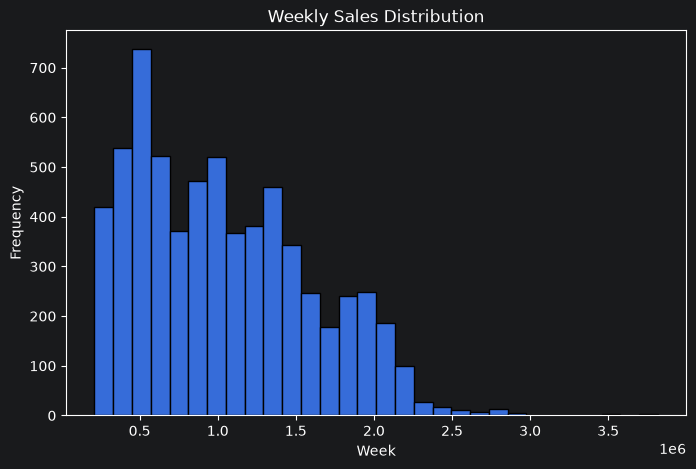

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['Weekly_Sales'],bins=30, edgecolor='black')
plt.xlabel('Week')
plt.ylabel('Frequency')
plt.title('Weekly Sales Distribution')
plt.savefig("images/weekly_sales_distribution.png",dpi=300,bbox_inches='tight')
plt.show()

### Boxplot (Outliers)

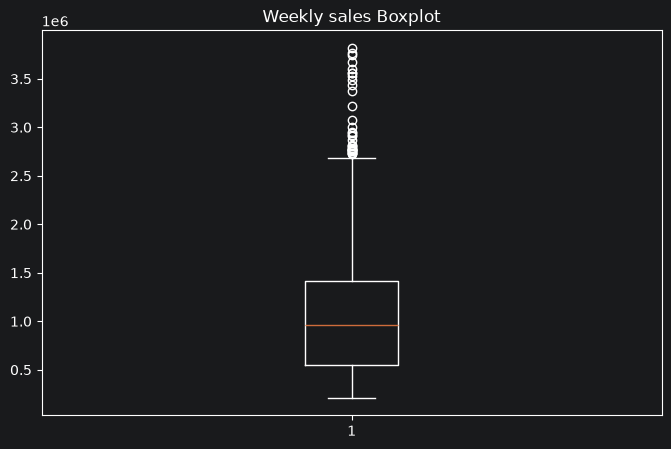

In [9]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Weekly_Sales"])
plt.title('Weekly sales Boxplot')
plt.savefig("images/Weekly_sales_Boxplot.png",dpi=300,bbox_inches='tight')
plt.show()

### Temperature vs Weekly Sales

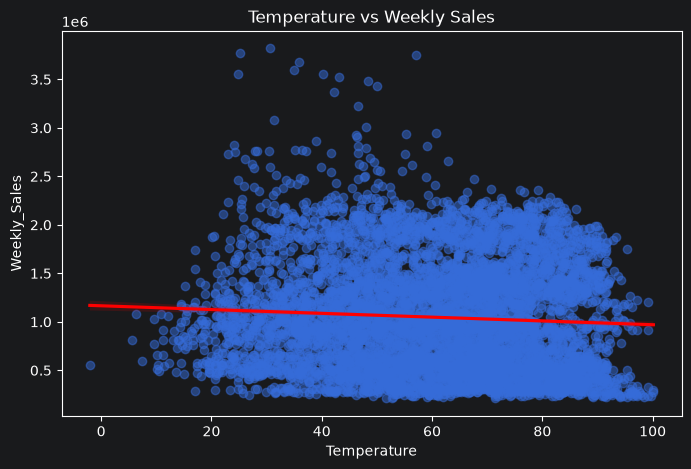

In [10]:
plt.figure(figsize=(8,5))
sns.regplot(
    data = df,
    x = 'Temperature',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Temperature vs Weekly Sales')
plt.savefig("images/Temperature_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Fuel Price vs Weekly Sales

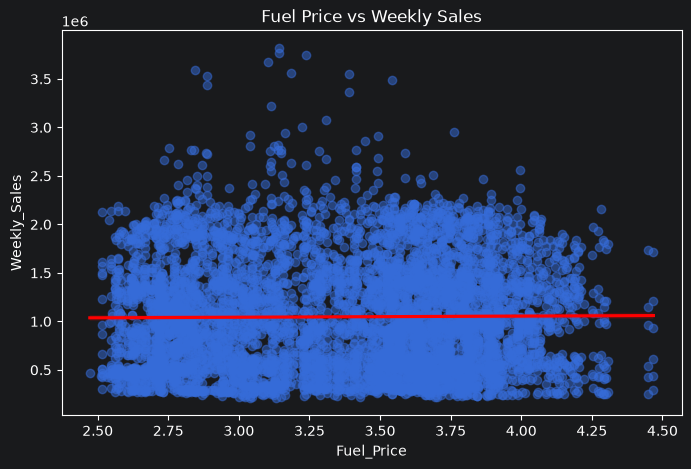

In [11]:
plt.figure(figsize=(8,5))

sns.regplot(
    data = df,
    x = 'Fuel_Price',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Fuel Price vs Weekly Sales')

plt.savefig("images/Fuel_Price_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### CPI vs Weekly Sales

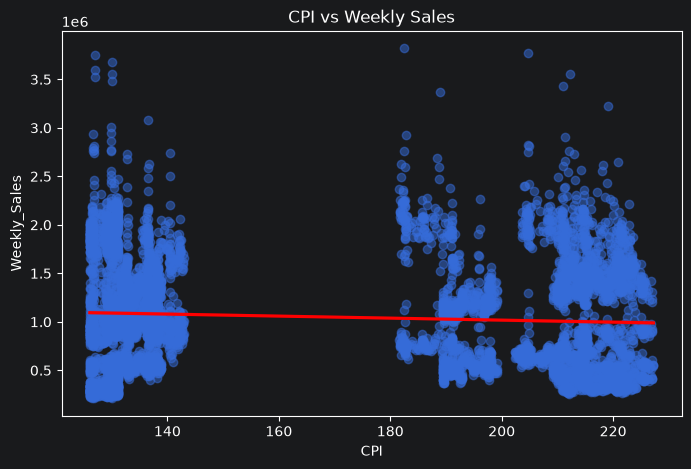

In [12]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data = df,
    x = 'CPI',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('CPI vs Weekly Sales')
plt.savefig("images/CPI_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Unemployment vs Weekly Sales

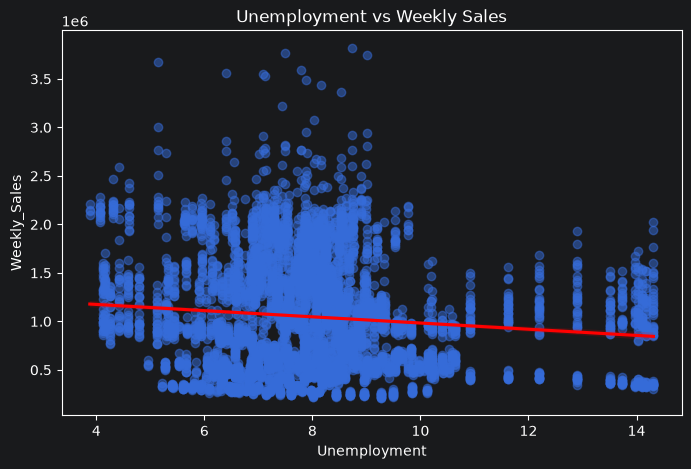

In [13]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data = df,
    x = 'Unemployment',
    y = 'Weekly_Sales',
    scatter_kws={'alpha':0.5},
    line_kws= {'color':'red'}
)
plt.title('Unemployment vs Weekly Sales')
plt.savefig("images/Unemployment_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Holiday vs Weekly Sales

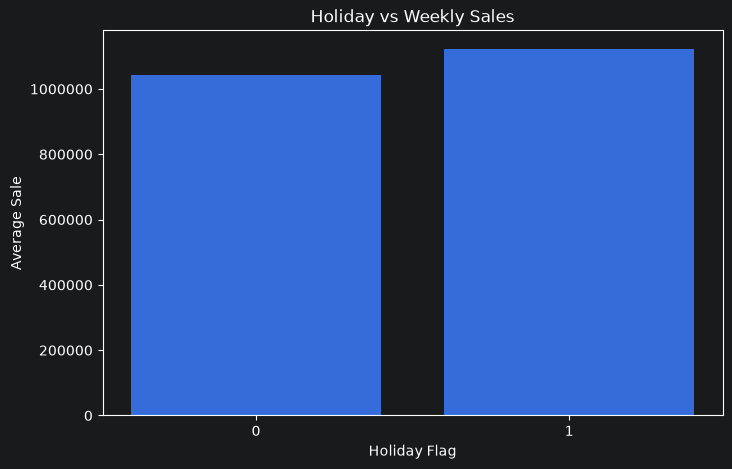

In [14]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
plt.figure(figsize=(8,5))
plt.bar(
    holiday_sales.index.astype(str),
    holiday_sales.values
)
plt.title('Holiday vs Weekly Sales')
plt.xlabel('Holiday Flag')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Holiday_vs_Weekly_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

### Monthly Sales Trend

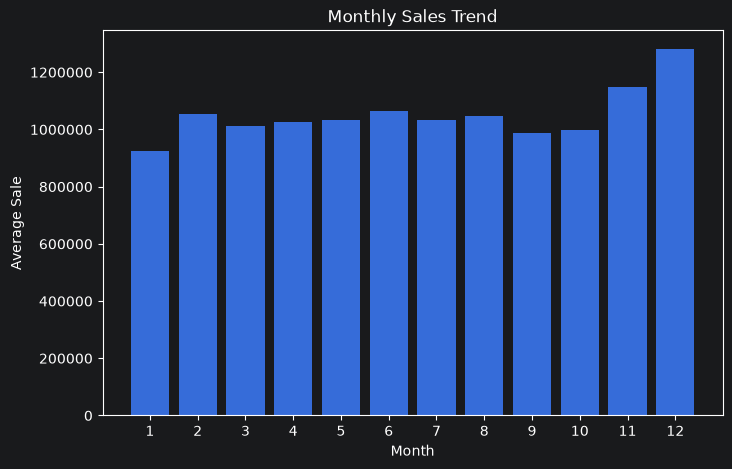

In [15]:
monthly_sales = df.groupby('Month')["Weekly_Sales"].mean()

plt.figure(figsize=(8,5))
plt.bar(
    monthly_sales.index.astype(str),
    monthly_sales.values,
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Monthly_Sales_Trend.png",dpi=300,bbox_inches='tight')
plt.show()

### Store Wise Sales

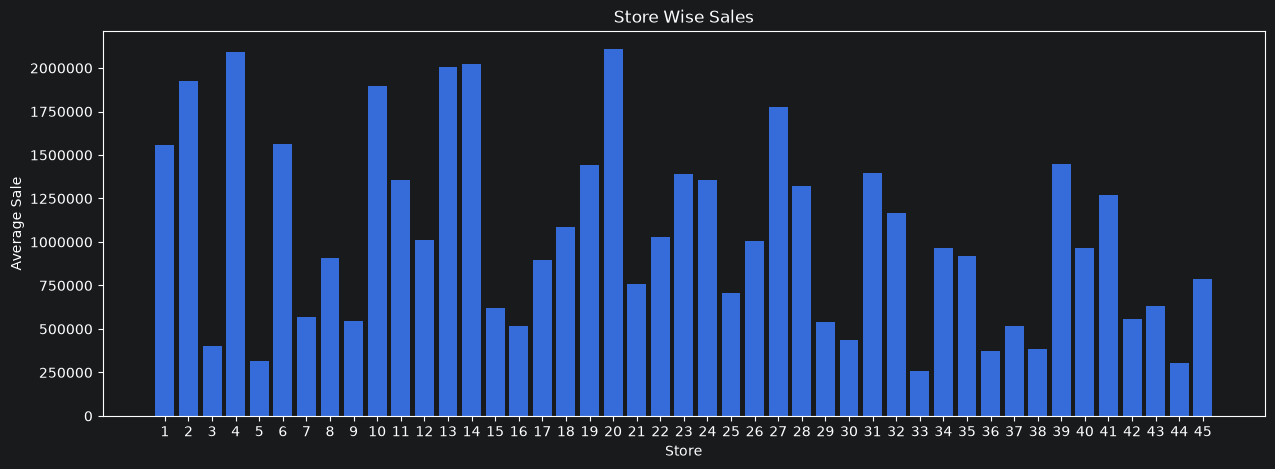

In [16]:
store_sales = df.groupby('Store')["Weekly_Sales"].mean()

plt.figure(figsize=(15,5))
plt.bar(
    store_sales.index.astype(str),
    store_sales.values
)
plt.title('Store Wise Sales')
plt.xlabel('Store')
plt.ylabel('Average Sale')

plt.ticklabel_format(style='plain',axis='y')
plt.savefig("images/Store_Wise_Sales.png",dpi=300,bbox_inches='tight')
plt.show()

## Heatmap

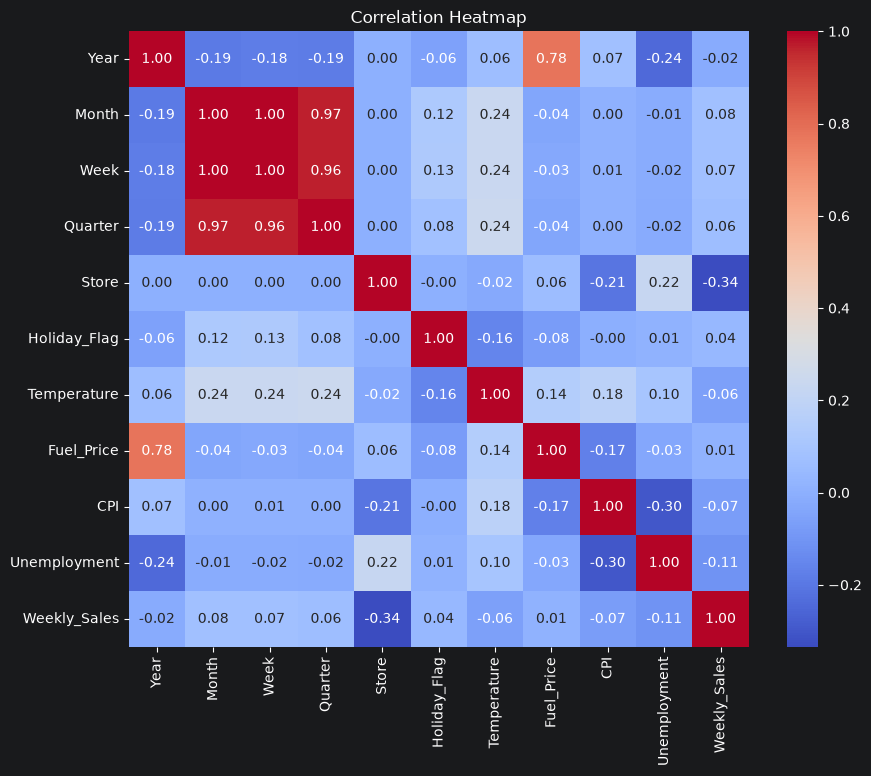

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('Correlation Heatmap')
plt.savefig("images/Heatmap.png",dpi=300,bbox_inches='tight')
plt.show()

## Feature Selection

In [18]:
target = df['Weekly_Sales']

features = df[['Year', 'Week', 'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

## Import

In [19]:
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.model_selection import KFold,cross_validate
from xgboost import XGBRegressor

from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)
import joblib

### Train-Test-Split

In [20]:
x_train,x_test,y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=42)

### Standardization

In [21]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
## Saving Scaler
joblib.dump(scaler,"./model/scaler.pxl")

['./model/scaler.pxl']

## Linear Regression

In [23]:
lr = LinearRegression()

## Lasso Regression

In [24]:
ls = Lasso(
    alpha=0.1,
    random_state=42
)

## XG Boost

In [25]:
xg = XGBRegressor(
    random_state=42
)

## Cross Validation

In [26]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'R2':'r2',
    'MAE':'neg_mean_absolute_error',
    'RMSE':'neg_root_mean_squared_error'
}

In [27]:
def cross_validation(model,x,y):
    scores = cross_validate(
        model,
        x,
        y,
        cv = cv,
        scoring = scoring
    )

    print("Avg R2: ",scores["test_R2"].mean())
    print("Avg MAE: ",-scores["test_MAE"].mean())
    print("Avg RMSE: ",-scores["test_RMSE"].mean())

In [28]:
# Linear Regression
cross_validation(
    lr,
    x_train_scaled,
    y_train,
)

Avg R2:  0.1424891928136167
Avg MAE:  429856.202417713
Avg RMSE:  521634.7255302303


In [29]:
# Lasso Regression
cross_validation(
    ls,
    x_train_scaled,
    y_train
)

Avg R2:  0.14248919446652364
Avg MAE:  429856.19857944536
Avg RMSE:  521634.7250806773


In [30]:
# XG Boost
cross_validation(
    xg,
    x_train,
    y_train
)

Avg R2:  0.9737453401255196
Avg MAE:  51887.92192251326
Avg RMSE:  90185.22120240534


### Selecting XG Boost model as it explains the data better than other models

In [31]:
xg.fit(x_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
from xgboost import plot_importance

<Figure size 1000x600 with 0 Axes>

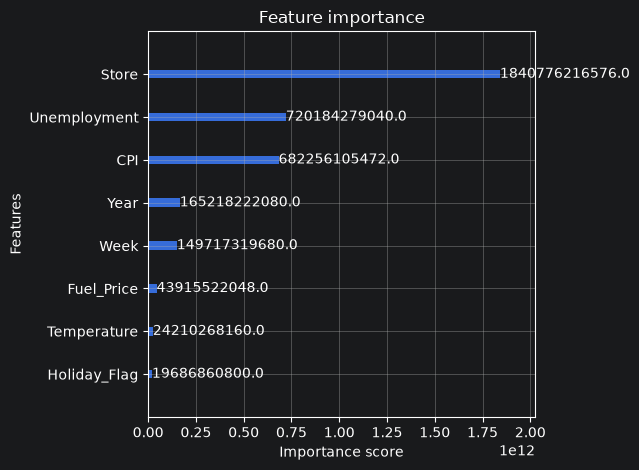

In [33]:
plt.figure(figsize=(10,6))

plot_importance( xg,importance_type="gain")

plt.tight_layout()
plt.savefig( "images/Feature_Importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
y_pred = xg.predict(x_test)

## Actual vs Predicted

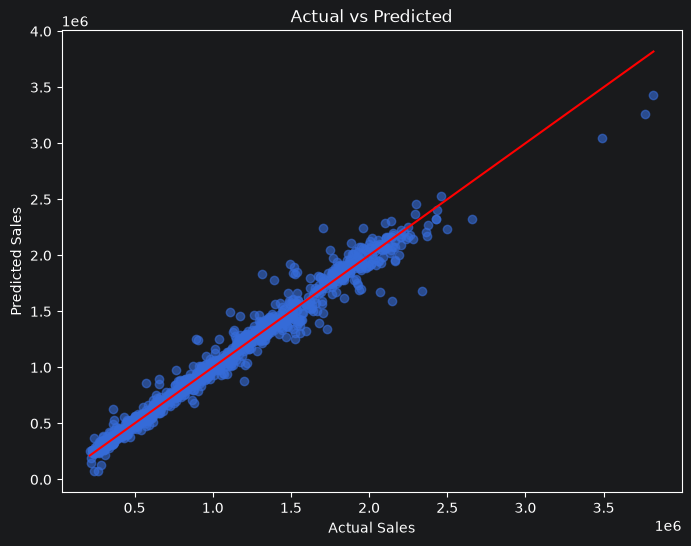

In [35]:
plt.figure(figsize=(8,6))

plt.scatter( y_test, y_pred, alpha=0.6)
plt.plot( [y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.savefig("images/Actual_vs_Predicted.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluation

In [36]:
def evaluate(y_test,y_pred):
    print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
    print(f"MSE : {mean_squared_error(y_test,y_pred)}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}")
    print(f"R² : {r2_score(y_test,y_pred)}")


In [37]:
evaluate(y_test,y_pred)

MAE : 50964.721990336046
MSE : 6983261273.169678
RMSE : 83565.90975493343
R² : 0.978323258336851
